# Astroformer Training for Galaxy10 DECals

Dieses Notebook trainiert ein Astroformer-Modell auf dem Galaxy10-DECals-Datensatz aus `data/Galaxy10_DECals.h5`.

Standard ist `astroformer_5`, weil das die Konfiguration ist, die im Astroformer-Repo fuer Galaxy10 angegeben wird. Wenn du ein kleineres Notebook fuer einen einzelnen GPU-Run brauchst, kannst du spaeter nur den Wert von `MODEL_NAME` aendern.

## Setup

Das Notebook nutzt die Astroformer-Implementierung aus dem offiziellen Repo. Falls sie lokal noch nicht verfuegbar ist, wird das Repo nach `third_party/Astroformer` geklont und der enthaltene `pytorch-image-models`-Ordner auf den Python-Pfad gesetzt.

Hinweis fuer Windows: Der DataLoader laeuft mit `num_workers = 0`, damit Notebook-Starts stabil bleiben.

In [1]:
from __future__ import annotations

import json
import math
import random
import subprocess
import sys
from contextlib import nullcontext
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'README.md').exists() and (candidate / 'data' / 'Galaxy10_DECals.h5').exists():
        PROJECT_ROOT = candidate
        break

DATA_PATH = PROJECT_ROOT / 'data' / 'Galaxy10_DECals.h5'
SRC_DIR = PROJECT_ROOT / 'src'
THIRD_PARTY_DIR = PROJECT_ROOT / 'third_party'
ASTROFORMER_DIR = THIRD_PARTY_DIR / 'Astroformer'
TIMM_PATH = ASTROFORMER_DIR / 'pytorch-image-models'

if not TIMM_PATH.exists():
    THIRD_PARTY_DIR.mkdir(parents=True, exist_ok=True)
    print('Astroformer repo not found locally. Cloning it now...')
    subprocess.run([
        'git', 'clone', '--depth', '1',
        'https://github.com/Rishit-dagli/Astroformer.git',
        str(ASTROFORMER_DIR),
    ], check=True)

sys.path.insert(0, str(TIMM_PATH))
sys.path.insert(0, str(SRC_DIR))

import timm
from data import LABEL_DICT, NUM_CLASSES, load_data, prepare_splits, print_class_distribution, show_class_distribution

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = torch.cuda.is_available()

print(f'Device: {device}')
print(f'CUDA available: {torch.cuda.is_available()}')
if device.type == 'cuda':
    try:
        print(f'GPU: {torch.cuda.get_device_name(0)}')
    except Exception:
        pass
print(f'timm version: {timm.__version__}')
print('Astroformer models:', ', '.join(timm.list_models('*astroformer*')))


c:\Users\alexa\Documents\Projects\deep-learning\torch-gpu-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 2070 SUPER
timm version: 0.9.10
Astroformer models: astroformer_0, astroformer_1, astroformer_2, astroformer_3, astroformer_4, astroformer_5


## Daten laden

Die Hilfsfunktionen aus `src/data.py` laden die HDF5-Datei direkt in NumPy-Arrays und zeigen die Klassenverteilung an.

Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)

Klasse   Beschreibung                              Anzahl
----------------------------------------------------------
0        Disturbed Galaxies                          1081
1        Merging Galaxies                            1853
2        Round Smooth Galaxies                       2645
3        In-between Round Smooth Galaxies            2027
4        Cigar Shaped Smooth Galaxies                 334
5        Barred Spiral Galaxies                      2043
6        Unbarred Tight Spiral Galaxies              1829
7        Unbarred Loose Spiral Galaxies              2628
8        Edge-on Galaxies without Bulge              1423
9        Edge-on Galaxies with Bulge                 1873
----------------------------------------------------------
GESAMT                                             17736


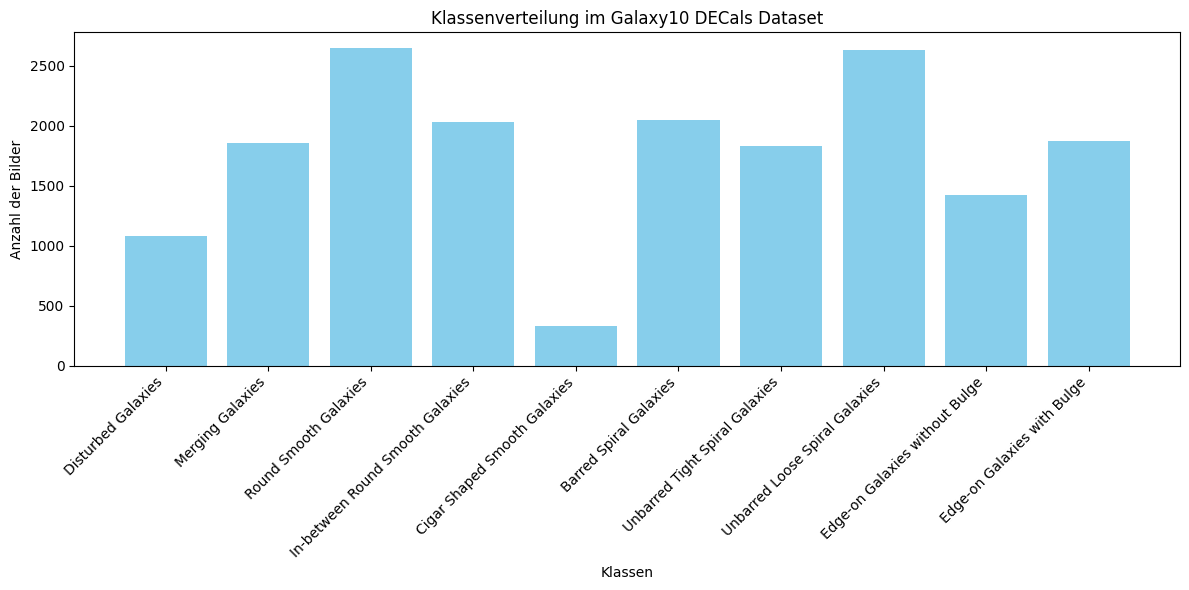

Bilder: (17736, 256, 256, 3)
Labels: (17736,)


In [2]:
images_raw, labels = load_data(str(DATA_PATH))
counts = print_class_distribution(labels)
show_class_distribution(counts)

print(f'Bilder: {images_raw.shape}')
print(f'Labels: {labels.shape}')

## Modell und Trainingskonfiguration

Das Notebook nutzt `astroformer_4` als Default, weil diese Variante im Astroformer-Repo die beste Gesamtbalance aus Genauigkeit und Rechenaufwand auf Galaxy10 DECals liefert.

Wenn du den Run auf einer kleineren GPU testen willst, aendere zuerst `MODEL_NAME` auf `astroformer_3`.

In [3]:
USE_KFOLD = False
VAL_SIZE = 0.2
TEST_SIZE = 0.2
BATCH_SIZE = 16
NUM_WORKERS = 0

folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold=USE_KFOLD,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=seed,
)
train_indices, val_indices = folds[0]

print(f'Train samples: {len(train_indices):,}')
print(f'Validation samples: {len(val_indices):,}')
print(f'Test samples: {len(X_test):,}')

IMG_SIZE = 256
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

class Galaxy10Dataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray, indices: np.ndarray, transform=None):
        self.images = images
        self.labels = labels
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, item: int):
        real_index = int(self.indices[item])
        image = Image.fromarray(self.images[real_index])
        label = int(self.labels[real_index])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_dataset = Galaxy10Dataset(images_raw, labels, train_indices, transform=train_transform)
val_dataset = Galaxy10Dataset(images_raw, labels, val_indices, transform=eval_transform)
test_dataset = Galaxy10Dataset(images_raw, labels, X_test, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Train samples: 11,350
Validation samples: 2,838
Test samples: 3,548


## Modell und Trainingskonfiguration

Das Notebook nutzt `astroformer_5` als Default, weil das die Astroformer-Konfiguration aus dem Repo fuer Galaxy10 ist.

Wenn du den Run auf einer kleineren GPU testen willst, aendere zuerst `MODEL_NAME` auf `astroformer_3` oder `astroformer_4`.

In [4]:
MODEL_NAME = 'astroformer_4'
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-2
EPOCHS = 30
LABEL_SMOOTHING = 0.1
EARLY_STOPPING_PATIENCE = 8


def build_model() -> nn.Module:
    model = timm.create_model(
        MODEL_NAME,
        pretrained=False,
        num_classes=NUM_CLASSES,
        in_chans=3,
        img_size=IMG_SIZE,
        drop_rate=0.1,
        drop_path_rate=0.1,
    )
    return model.to(device)

model = build_model()
num_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model.__class__.__name__)
print(f'Parameter: {num_parameters:,}')

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
autocast_context = torch.amp.autocast if torch.cuda.is_available() else nullcontext

logs_dir = PROJECT_ROOT / 'logs' / 'astroformer'
reports_dir = PROJECT_ROOT / 'reports' / 'astroformer'
logs_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = logs_dir / f'{MODEL_NAME}_best.pt'

# Run identification and TensorBoard writer (similar to Zoobot notebook)
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"astro_{MODEL_NAME}_{RUN_ID}"
print(f"Run name: {run_name}")
print(f"Logs dir: {logs_dir / run_name}")
writer = SummaryWriter(log_dir=str(logs_dir / run_name))

No pretrained configuration specified for astroformer_4 model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
c:\Users\alexa\Documents\Projects\deep-learning\torch-gpu-env\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


MaxxVit
Parameter: 241,088,650
Run name: astro_astroformer_4_20260528_172327
Logs dir: C:\Users\alexa\Documents\Projects\deep-learning\logs\astroformer\astro_astroformer_4_20260528_172327


In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None, train: bool = True):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    epoch_desc = 'Train' if train else 'Val'
    loader_iter = tqdm(loader, desc=epoch_desc, leave=False)

    for images, targets in loader_iter:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with autocast_context("cuda"):
                logits = model(images)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                with autocast_context("cuda"):
                    logits = model(images)
                    loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        y_true.extend(targets.detach().cpu().tolist())
        y_pred.extend(predictions.detach().cpu().tolist())

        loader_iter.set_postfix(
            loss=f'{loss.item():.4f}',
            acc=f'{accuracy_score(y_true, y_pred):.4f}',
        )

    average_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(y_true, y_pred)
    return average_loss, accuracy, y_true, y_pred

history_rows = []
best_val_accuracy = -math.inf
best_state_dict = None
patience = 0

for epoch in range(1, EPOCHS + 1):
    print(f'\nEpoch {epoch:03d}/{EPOCHS}')
    train_loss, train_accuracy, _, _ = run_one_epoch(
        model, train_loader, criterion, optimizer=optimizer, train=True
    )
    val_loss, val_accuracy, _, _ = run_one_epoch(
        model, val_loader, criterion, optimizer=None, train=False
    )
    scheduler.step()

    history_rows.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'lr': scheduler.get_last_lr()[0],
    })

    print(
        f'Epoch {epoch:03d} | '
        f'train loss {train_loss:.4f} acc {train_accuracy:.4f} | '
        f'val loss {val_loss:.4f} acc {val_accuracy:.4f} | '
        f'lr {scheduler.get_last_lr()[0]:.2e}'
    )

    # TensorBoard logging (train & val)
    try:
        writer.add_scalar('Loss/Train', float(train_loss), epoch)
        writer.add_scalar('Loss/Validation', float(val_loss), epoch)
        writer.add_scalar('Accuracy/Train', float(train_accuracy), epoch)
        writer.add_scalar('Accuracy/Validation', float(val_accuracy), epoch)
        writer.add_scalar('LR', float(scheduler.get_last_lr()[0]), epoch)
    except Exception:
        pass

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        torch.save(best_state_dict, best_checkpoint_path)
        print(f'  -> Neues bestes Modell gespeichert: {best_checkpoint_path}')
        patience = 0
    else:
        patience += 1
        if patience >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping after {epoch} epochs.')
            break

history = pd.DataFrame(history_rows)
history_path = reports_dir / f'{MODEL_NAME}_history.csv'
history.to_csv(history_path, index=False)
print(f'History saved to: {history_path}')

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# Close the TensorBoard writer
try:
    writer.close()
    print(f'TensorBoard logs written to: {logs_dir / run_name}')
except Exception:
    pass

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='train')
plt.plot(history['epoch'], history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['train_accuracy'], label='train')
plt.plot(history['epoch'], history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
curve_path = reports_dir / f'{MODEL_NAME}_training_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Curves saved to: {curve_path}')



Epoch 001/30


TypeError: autocast.__init__() missing 1 required positional argument: 'device_type'

## Testauswertung

Zum Schluss wird das beste Modell auf dem festen Test-Split ausgewertet. Die Konfusionsmatrix und ein Report werden unter `reports/astroformer/` gespeichert.

In [ ]:
test_loss, test_accuracy, y_true, y_pred = run_one_epoch(
    model, test_loader, criterion, optimizer=None, train=False
)

class_names = [LABEL_DICT[index] for index in range(NUM_CLASSES)]
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_path = reports_dir / f'{MODEL_NAME}_classification_report.csv'
report_df.to_csv(report_path)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {MODEL_NAME}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
cm_path = reports_dir / f'{MODEL_NAME}_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

metrics = {
    'model_name': MODEL_NAME,
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'best_val_accuracy': float(best_val_accuracy),
    'num_parameters': int(num_parameters),
    'checkpoint_path': str(best_checkpoint_path),
    'history_path': str(history_path),
    'report_path': str(report_path),
    'confusion_matrix_path': str(cm_path),
}
metrics_path = reports_dir / f'{MODEL_NAME}_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print(json.dumps(metrics, indent=2))
print(f'Metrics saved to: {metrics_path}')